# PHASE 1: Setup & EDA


# Step 1: Import Libraries


In [ ]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import itertools
import warnings

warnings.filterwarnings("ignore")

I0000 00:00:1779822353.755222   54216 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779822353.780897   54216 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779822354.398797   54216 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Step 2: Set Random Seed


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Step 3: Define Dataset Path


In [ ]:
DATA_DIR = "chest-xray-pneumonia-balanced-dataset"  # <-- change this
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("Train:", TRAIN_DIR)
print("Val:", VAL_DIR)
print("Test:", TEST_DIR)

Train: chest-xray-pneumonia-balanced-dataset/train
Val: chest-xray-pneumonia-balanced-dataset/val
Test: chest-xray-pneumonia-balanced-dataset/test


# Step 4: Check Class Distribution


In [ ]:
def count_images(folder):
    classes = sorted(os.listdir(folder))
    counts = {}
    for c in classes:
        p = os.path.join(folder, c)
        if os.path.isdir(p):
            counts[c] = len(os.listdir(p))
    return counts


print("Train distribution:", count_images(TRAIN_DIR))
print("Val distribution:", count_images(VAL_DIR))
print("Test distribution:", count_images(TEST_DIR))

Train distribution: {'NORMAL': 3400, 'PNEUMONIA': 3400}
Val distribution: {'NORMAL': 850, 'PNEUMONIA': 850}
Test distribution: {'NORMAL': 15, 'PNEUMONIA': 15}


# Step 5: Visualize Random Images


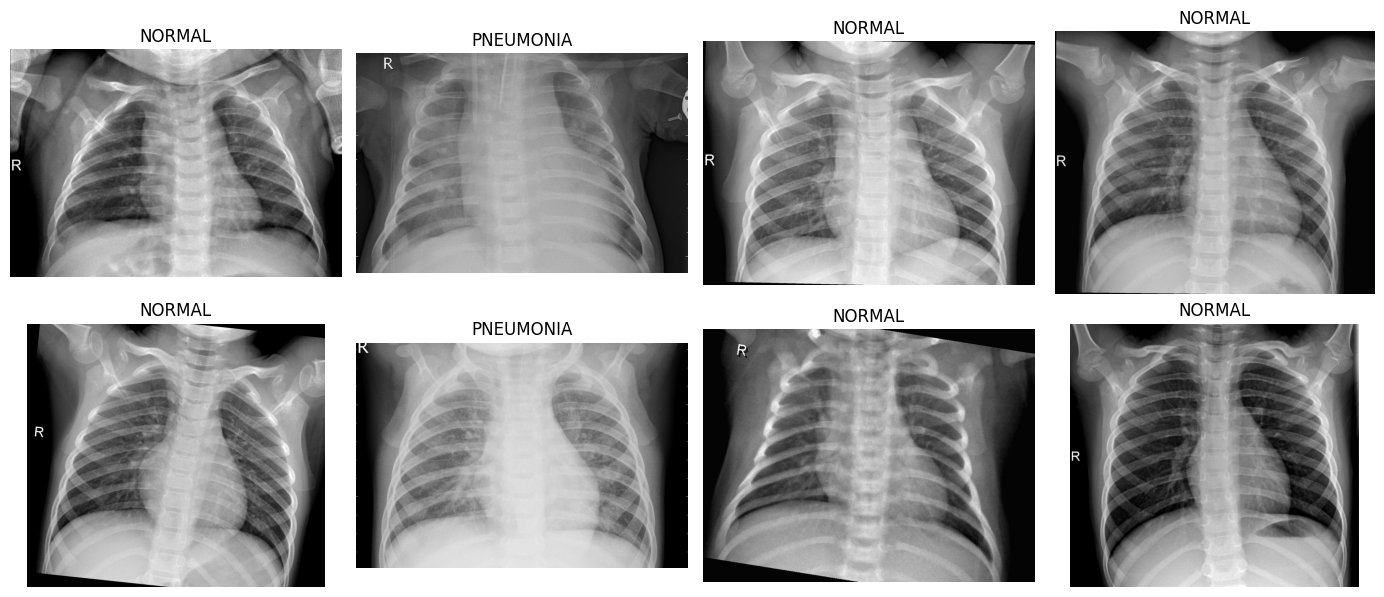

In [ ]:
def show_random_images(folder, n=8):
    classes = sorted(
        [c for c in os.listdir(folder) if os.path.isdir(os.path.join(folder, c))]
    )
    plt.figure(figsize=(14, 6))
    for i in range(n):
        cls = random.choice(classes)
        img_name = random.choice(os.listdir(os.path.join(folder, cls)))
        img_path = os.path.join(folder, cls, img_name)
        img = tf.keras.utils.load_img(img_path)
        plt.subplot(2, n // 2, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(cls)
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_random_images(TRAIN_DIR, n=8)

# Step 6: Check Image Size & Channels


In [ ]:
sample_cls = sorted(os.listdir(TRAIN_DIR))[0]
sample_img = os.listdir(os.path.join(TRAIN_DIR, sample_cls))[0]
sample_path = os.path.join(TRAIN_DIR, sample_cls, sample_img)

img = tf.keras.utils.load_img(sample_path)
arr = tf.keras.utils.img_to_array(img)

print("Sample path:", sample_path)
print("Image shape:", arr.shape)  # (H, W, C)

Sample path: chest-xray-pneumonia-balanced-dataset/train/NORMAL/NORMAL2-IM-0821-0001_aug_704.jpg
Image shape: (1487, 1836, 3)


# PHASE 2: Data Preparation


## X-ray is grayscale, The pretrained model is 3-channel RGB expect color_mode='rgb'


# Common Config


In [ ]:
IMG_SIZE = (224, 224)  # MobileNetV2/ResNet50/DenseNet121/EfficientNetB0 এর জন্য safe
BATCH_SIZE = 32

# Step 7: Train Augmentation


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    horizontal_flip=True,
    fill_mode="nearest",
)

# Step 8: Validation/Test Generator


In [ ]:
test_val_datagen = ImageDataGenerator(rescale=1.0 / 255)

# Step 9: Load Generators


In [ ]:
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED,
)

val_gen = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False,
)

test_gen = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False,
)

print("Class indices:", train_gen.class_indices)  # e.g. {'NORMAL':0, 'PNEUMONIA':1}

Found 6800 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


# Step 10: Compute Class Weights


In [ ]:
y_train = train_gen.classes
classes = np.unique(y_train)

weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = {int(c): w for c, w in zip(classes, weights)}
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.0), 1: np.float64(1.0)}


# PHASE 3: Model Building


In [ ]:
def build_pretrained_model(base_model, img_size=(224, 224), lr=1e-4, dropout=0.3):
    base_model.trainable = False  # first stage freeze

    inputs = layers.Input(shape=(img_size[0], img_size[1], 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

# PHASE 4: Train 5 Pretrained Models


In [ ]:
def get_callbacks(name):
    return [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, verbose=1),
        ModelCheckpoint(
            f"{name}_best.keras",
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
    ]

# Helper Train Function


In [ ]:
def train_model(model, name, epochs=15):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        class_weight=class_weights,
        callbacks=get_callbacks(name),
        verbose=1,
    )
    return history

# Step 12: Train MobileNetV2


In [ ]:
base = tf.keras.applications.MobileNetV2(
    include_top=False, weights="imagenet", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
mobilenet_model = build_pretrained_model(base, IMG_SIZE, lr=1e-4, dropout=0.3)
mobilenet_hist = train_model(mobilenet_model, "MobileNetV2", epochs=15)

W0000 00:00:1779822357.624672   54216 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15


I0000 00:00:1779822359.254608   54216 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.6270 - auc: 0.6761 - loss: 0.6605
Epoch 1: val_auc improved from None to 0.91811, saving model to MobileNetV2_best.keras

Epoch 1: finished saving model to MobileNetV2_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 85s 394ms/step - accuracy: 0.6937 - auc: 0.7633 - loss: 0.5788 - val_accuracy: 0.8435 - val_auc: 0.9181 - val_loss: 0.4378 - learning_rate: 1.0000e-04
Epoch 2/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.8161 - auc: 0.8994 - loss: 0.4193
Epoch 2: val_auc improved from 0.91811 to 0.95435, saving model to MobileNetV2_best.keras

Epoch 2: finished saving model to MobileNetV2_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 82s 385ms/step - accuracy: 0.8299 - auc: 0.9098 - loss: 0.3994 - val_accuracy: 0.8853 - val_auc: 0.9543 - val_loss: 0.3351 - learning_rate: 1.0000e-04
Epoch 3/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.8662 - auc: 0.9397 - loss: 0.3356
Epoch 3: val_auc improved from 0.95435 to 0.96602, s

KeyboardInterrupt: 

# Step 13: Train ResNet50


In [ ]:
base = tf.keras.applications.ResNet50(
    include_top=False, weights="imagenet", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
resnet_model = build_pretrained_model(base, IMG_SIZE, lr=1e-4, dropout=0.3)
resnet_hist = train_model(resnet_model, "ResNet50", epochs=5)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 642ms/step - accuracy: 0.5008 - auc: 0.5058 - loss: 0.7260
Epoch 1: val_auc improved from -inf to 0.55932, saving model to ResNet50_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 177s 768ms/step - accuracy: 0.5008 - auc: 0.5058 - loss: 0.7260 - val_accuracy: 0.5482 - val_auc: 0.5593 - val_loss: 0.6922 - learning_rate: 1.0000e-04
Epoch 2/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 648ms/step - accuracy: 0.4974 - auc: 0.5006 - loss: 0.7202
Epoch 2: val_auc improved from 0.55932 to 0.79754, saving model to ResNet50_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 158s 739ms/step - accuracy: 0.4975 - auc: 0.5007 - loss: 0.7202 - val_accuracy: 0.6776 - val_auc: 0.7975 - val_loss: 0.6849 - learning_rate: 1.0000e-04
Epoch 3/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.5233 - auc: 0.5259 - loss: 0.7066
Epoch 3: val_auc improved from 0.79754 to 0.83607, saving model to ResNet50_best.keras
213/213 ━━━━━━━━━━━━━━━━━━

# Step 13: Train ResNet50


In [ ]:
base = tf.keras.applications.ResNet50(
    include_top=False, weights="imagenet", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
resnet_model = build_pretrained_model(base, IMG_SIZE, lr=1e-4, dropout=0.3)
resnet_hist = train_model(resnet_model, "ResNet50", epochs=15)

Epoch 1/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.4989 - auc: 0.4893 - loss: 0.7416
Epoch 1: val_auc improved from -inf to 0.73537, saving model to ResNet50_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 165s 726ms/step - accuracy: 0.4989 - auc: 0.4894 - loss: 0.7416 - val_accuracy: 0.5000 - val_auc: 0.7354 - val_loss: 0.6894 - learning_rate: 1.0000e-04
Epoch 2/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.5135 - auc: 0.5119 - loss: 0.7216
Epoch 2: val_auc improved from 0.73537 to 0.83564, saving model to ResNet50_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 145s 679ms/step - accuracy: 0.5135 - auc: 0.5119 - loss: 0.7216 - val_accuracy: 0.5000 - val_auc: 0.8356 - val_loss: 0.6829 - learning_rate: 1.0000e-04
Epoch 3/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.5287 - auc: 0.5296 - loss: 0.7070
Epoch 3: val_auc improved from 0.83564 to 0.85146, saving model to ResNet50_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 141s 663ms/step - accuracy: 0.5287 - auc: 0.5

# Step 14: Train InceptionV3


In [ ]:
IMG_SIZE_INC = (299, 299)

train_gen_inc = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE_INC,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=True,
    seed=SEED,
)
val_gen_inc = test_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE_INC,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False,
)
test_gen_inc = test_val_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE_INC,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    color_mode="rgb",
    shuffle=False,
)

base = tf.keras.applications.InceptionV3(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE_INC[0], IMG_SIZE_INC[1], 3),
)
inception_model = build_pretrained_model(base, IMG_SIZE_INC, lr=1e-4, dropout=0.3)

inception_hist = inception_model.fit(
    train_gen_inc,
    validation_data=val_gen_inc,
    epochs=15,
    class_weight=class_weights,
    callbacks=get_callbacks("InceptionV3"),
    verbose=1,
)

Found 6800 images belonging to 2 classes.
Found 1700 images belonging to 2 classes.
Found 30 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 893ms/step - accuracy: 0.6346 - auc: 0.7041 - loss: 0.6187
Epoch 1: val_auc improved from -inf to 0.94848, saving model to InceptionV3_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 245s 1s/step - accuracy: 0.6351 - auc: 0.7046 - loss: 0.6183 - val_accuracy: 0.8512 - val_auc: 0.9485 - val_loss: 0.4274 - learning_rate: 1.0000e-04
Epoch 2/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 828ms/step - accuracy: 0.8704 - auc: 0.9362 - loss: 0.3795
Epoch 2: val_auc improved from 0.94848 to 0.96528, saving model to InceptionV3_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 198s 929ms/step - accuracy: 0.8704 - auc: 0.9363 - loss: 0.3794 - val_accuracy: 0.8712 - val_auc: 0.9653 - val_loss: 0.3418 - learning_rate: 1.0000e-04
Epoch 3/15
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 856ms/step - accuracy: 0.8853 - auc: 0.952

# Step 15: Train EfficientNetB0


In [ ]:
base = tf.keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
effnet_model = build_pretrained_model(base, IMG_SIZE, lr=1e-4, dropout=0.3)
effnet_hist = train_model(effnet_model, "EfficientNetB0", epochs=5)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5


2026-02-17 23:41:35.194618: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:41:35.337956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:41:35.689487: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:41:35.831495: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:41:36.579441: E external/local_xla/xla/stream_

192/213 ━━━━━━━━━━━━━━━━━━━━ 12s 583ms/step - accuracy: 0.5049 - auc: 0.5139 - loss: 0.6949

2026-02-17 23:43:39.552821: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:43:39.692654: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:43:40.021426: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:43:40.162966: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:43:40.884667: E external/local_xla/xla/stream_

213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 637ms/step - accuracy: 0.5039 - auc: 0.5118 - loss: 0.6952

2026-02-17 23:44:25.545949: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:44:25.681217: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:44:26.000015: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:44:26.141899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-17 23:44:26.851511: E external/local_xla/xla/stream_


Epoch 1: val_auc improved from -inf to 0.50000, saving model to EfficientNetB0_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 191s 793ms/step - accuracy: 0.5039 - auc: 0.5118 - loss: 0.6952 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6937 - learning_rate: 1.0000e-04
Epoch 2/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.5027 - auc: 0.5034 - loss: 0.6965
Epoch 2: val_auc did not improve from 0.50000
213/213 ━━━━━━━━━━━━━━━━━━━━ 141s 661ms/step - accuracy: 0.5026 - auc: 0.5034 - loss: 0.6965 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6933 - learning_rate: 1.0000e-04
Epoch 3/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.5062 - auc: 0.5076 - loss: 0.6957
Epoch 3: val_auc did not improve from 0.50000
213/213 ━━━━━━━━━━━━━━━━━━━━ 143s 669ms/step - accuracy: 0.5061 - auc: 0.5076 - loss: 0.6957 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.6932 - learning_rate: 1.0000e-04
Epoch 4/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.5004 

# Step 16: Train DenseNet121


In [ ]:
base = tf.keras.applications.DenseNet121(
    include_top=False, weights="imagenet", input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
densenet_model = build_pretrained_model(base, IMG_SIZE, lr=1e-4, dropout=0.3)
densenet_hist = train_model(densenet_model, "DenseNet121", epochs=5)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 678ms/step - accuracy: 0.4714 - auc: 0.4626 - loss: 0.8426
Epoch 1: val_auc improved from -inf to 0.86017, saving model to DenseNet121_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 215s 877ms/step - accuracy: 0.4716 - auc: 0.4630 - loss: 0.8423 - val_accuracy: 0.7776 - val_auc: 0.8602 - val_loss: 0.5561 - learning_rate: 1.0000e-04
Epoch 2/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.6801 - auc: 0.7499 - loss: 0.5904
Epoch 2: val_auc improved from 0.86017 to 0.95060, saving model to DenseNet121_best.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 153s 717ms/step - accuracy: 0.6803 - auc: 0.7501 - loss: 0.5902 - val_accuracy: 0.8665 - val_auc: 0.9506 - val_loss: 0.4419 - learning_rate: 1.0000e-04
Epoch 3/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.7932 - auc: 0.8748 - loss: 0.4679
Epoch 3: val_auc improved from 0.95060 to 0.96578, saving model to DenseNet121_best.keras
213/213 ━━━━━━━━━

# PHASE 5: Learning Curve Analysis

# Step 17: Plot Accuracy Curve


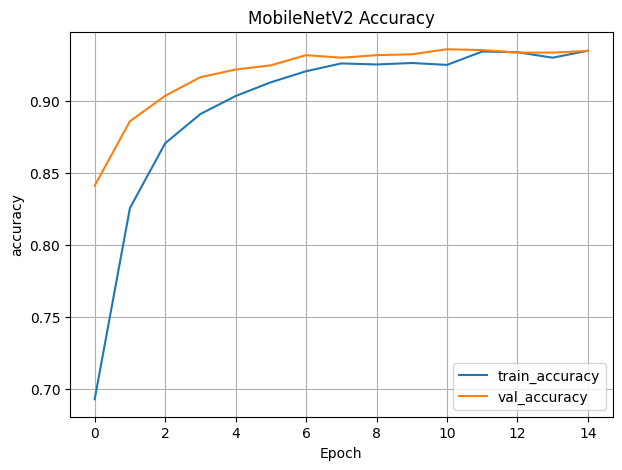

In [ ]:
def plot_metric(history, metric="accuracy", title="Accuracy Curve"):
    plt.figure(figsize=(7, 5))
    plt.plot(history.history[metric], label=f"train_{metric}")
    plt.plot(history.history[f"val_{metric}"], label=f"val_{metric}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()


plot_metric(mobilenet_hist, "accuracy", "MobileNetV2 Accuracy")

# Step 18: Plot Loss Curve


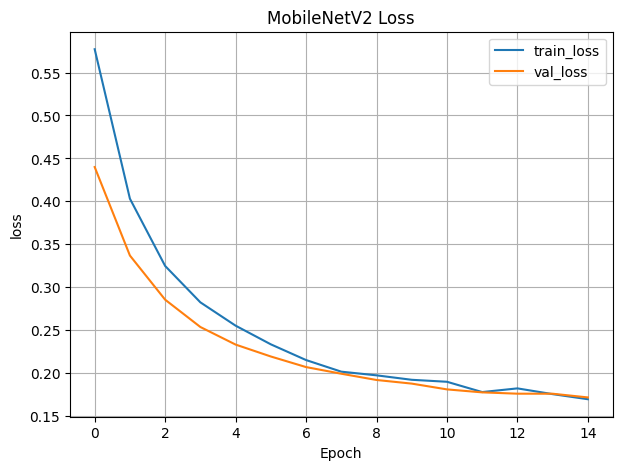

In [ ]:
def plot_loss(history, title="Loss Curve"):
    plt.figure(figsize=(7, 5))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(True)
    plt.show()


plot_loss(mobilenet_hist, "MobileNetV2 Loss")

# PHASE 6: Advanced Evaluation (Binary Class)


# Step 19: Evaluate Test Accuracy


In [ ]:
test_loss, test_acc, test_auc = mobilenet_model.evaluate(test_gen, verbose=1)
print("Test Loss:", test_loss)
print("Test Acc:", test_acc)
print("Test AUC:", test_auc)

2026-02-18 00:08:19.368954: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 00:08:19.506409: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step - accuracy: 0.9667 - auc: 1.0000 - loss: 0.1247
Test Loss: 0.1247318685054779
Test Acc: 0.9666666388511658
Test AUC: 1.0


# Step 20: Confusion Matrix


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


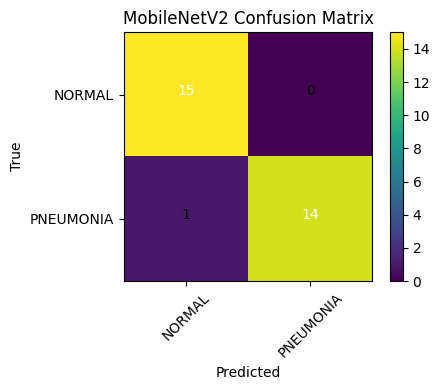

In [ ]:
def plot_confusion_matrix(cm, classes, title="Confusion Matrix"):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j,
            i,
            cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black",
        )
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


y_true = test_gen.classes
y_prob = mobilenet_model.predict(test_gen).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_true, y_pred)
class_names = list(test_gen.class_indices.keys())
plot_confusion_matrix(cm, class_names, "MobileNetV2 Confusion Matrix")

# Step 21: Classification Report


In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      NORMAL       0.94      1.00      0.97        15
   PNEUMONIA       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Step 22: ROC Curve (Binary)


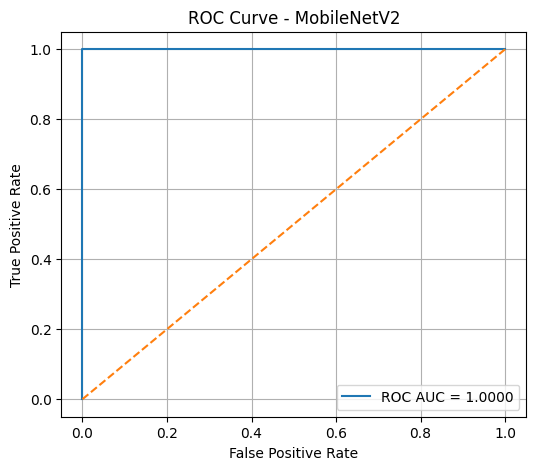

In [ ]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MobileNetV2")
plt.legend()
plt.grid(True)
plt.show()

# Step 23: Calculate AUC Score


In [ ]:
print("AUC:", roc_auc)

AUC: 1.0


In [ ]:
def evaluate_model(model, test_generator, name="Model"):
    y_true = test_generator.classes
    y_prob = model.predict(test_generator).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    loss, acc, model_auc = model.evaluate(test_generator, verbose=0)
    print(f"\n{name} -> Loss:{loss:.4f}  Acc:{acc:.4f}  AUC(metric):{model_auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(
        cm, list(test_generator.class_indices.keys()), f"{name} Confusion Matrix"
    )

    print(
        classification_report(
            y_true, y_pred, target_names=list(test_generator.class_indices.keys())
        )
    )

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(f"ROC - {name}")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.legend()
    plt.grid(True)
    plt.show()

    return roc_auc


# Example:
# evaluate_model(resnet_model, test_gen, "ResNet50")

In [ ]:
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)


def eval_binary_model(model, test_generator, name="Model"):
    y_true = test_generator.classes
    y_prob = model.predict(test_generator, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    # confusion matrix values
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metrics
    acc = (tp + tn) / (tp + tn + fp + fn)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)  # sensitivity for class 1
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    # Specificity
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "Model": name,
        "Accuracy": acc,
        "AUC": auc,
        "Precision": prec,
        "Recall(Sens)": rec,
        "Specificity": spec,
        "F1": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }


results = []

# 224x224 models
results.append(eval_binary_model(mobilenet_model, test_gen, "MobileNetV2"))
results.append(eval_binary_model(resnet_model, test_gen, "ResNet50"))
results.append(eval_binary_model(effnet_model, test_gen, "EfficientNetB0"))
results.append(eval_binary_model(densenet_model, test_gen, "DenseNet121"))

# 299x299 model
results.append(eval_binary_model(inception_model, test_gen_inc, "InceptionV3"))

df = pd.DataFrame(results)

# Sort by AUC then Recall then F1 (medical-friendly)
df_sorted = df.sort_values(
    by=["AUC", "Recall(Sens)", "F1"], ascending=False
).reset_index(drop=True)

print(df_sorted)

2026-02-18 00:08:53.129400: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 00:08:53.273205: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 00:08:53.619157: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 00:08:53.760630: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-18 00:08:54.494090: E external/local_xla/xla/stream_

            Model  Accuracy       AUC  Precision  Recall(Sens)  Specificity  \
0     InceptionV3  0.966667  1.000000   0.937500      1.000000     0.933333   
1     MobileNetV2  0.966667  1.000000   1.000000      0.933333     1.000000   
2     DenseNet121  0.900000  0.973333   0.928571      0.866667     0.933333   
3        ResNet50  0.866667  0.906667   0.923077      0.800000     0.933333   
4  EfficientNetB0  0.500000  0.546667   0.500000      1.000000     0.000000   

         F1  TP  FP  FN  TN  
0  0.967742  15   1   0  14  
1  0.965517  14   0   1  15  
2  0.896552  13   1   2  14  
3  0.857143  12   1   3  14  
4  0.666667  15  15   0   0  
